In [28]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from sklearn.preprocessing import LabelEncoder
from torchvision import models

In [11]:
train_data = pd.read_csv('/kaggle/input/datasets/marquis03/bean-leaf-lesions-classification/train.csv')
val_data = pd.read_csv('/kaggle/input/datasets/marquis03/bean-leaf-lesions-classification/val.csv')

train_data['image:FILE'] = '/kaggle/input/datasets/marquis03/bean-leaf-lesions-classification/' + train_data['image:FILE']
val_data['image:FILE'] = '/kaggle/input/datasets/marquis03/bean-leaf-lesions-classification/' + val_data['image:FILE']
train_data.head()

,image:FILE,category
0,/kaggle/input/datasets/marquis03/bean-leaf-les...,0
1,/kaggle/input/datasets/marquis03/bean-leaf-les...,0
2,/kaggle/input/datasets/marquis03/bean-leaf-les...,0
3,/kaggle/input/datasets/marquis03/bean-leaf-les...,0
4,/kaggle/input/datasets/marquis03/bean-leaf-les...,0


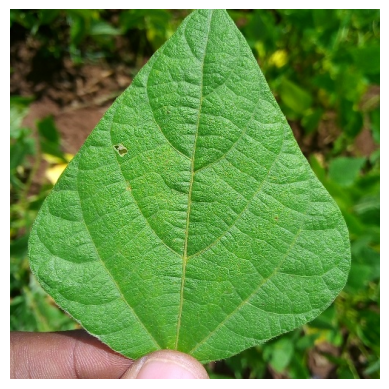

In [12]:
test_image = train_data.iloc[0]['image:FILE']
image = Image.open(test_image)
# Show image
plt.imshow(image)
plt.axis("off")   # remove axis
plt.show()

In [16]:
transform = transforms.Compose([  
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [20]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform = None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return self.dataframe.shape[0]



    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 1]
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(label, dtype=torch.long)

        return image, label

    

In [23]:
train_dataset = CustomImageDataset(dataframe=train_data, transform=transform)
val_dataset = CustomImageDataset(dataframe=val_data, transform=transform)

In [27]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 15

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [29]:
model = models.googlenet(
    weights=models.GoogLeNet_Weights.DEFAULT
)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 192MB/s]


In [39]:
for param in model.parameters():
    param.requires_grad = True

In [40]:
model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [42]:
num_classes = len(train_data['category'].unique())

In [44]:
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [46]:
model = model.to(device)

In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = LR)

In [51]:
train_loss_total = []
train_acc_total = []
val_loss_total = []
val_acc_total = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for data, label in train_loader:
        data = data.to(device)
        label = label.to(device)

        prediction = model(data)
        loss = criterion(prediction, label)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        predicted_class = torch.argmax(prediction, dim=1)
        correct += (predicted_class == label).sum().item()
        total += label.size(0)

    
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = correct / total


    # Validation

    model.eval()
    val_loss = 0
    correct = 0
    total = 0


    with torch.no_grad():

        for data, label in val_loader:
            data = data.to(device)
            label = label.to(device)
    
            prediction = model(data)
            loss = criterion(prediction, label)
            val_loss += loss.item()
            predicted_class = torch.argmax(prediction, dim=1)
            correct += (predicted_class == label).sum().item()
            total += label.size(0)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = correct / total

    train_loss_total.append(avg_train_loss)
    train_acc_total.append(avg_train_acc)
    val_loss_total.append(avg_val_loss)
    val_acc_total.append(avg_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")        
    

Epoch 1/15 | Train Loss: 0.7591 | Train Acc: 0.6615 | Val Loss: 0.3650 | Val Acc: 0.9023
Epoch 2/15 | Train Loss: 0.2717 | Train Acc: 0.9284 | Val Loss: 0.2152 | Val Acc: 0.9398
Epoch 3/15 | Train Loss: 0.1096 | Train Acc: 0.9787 | Val Loss: 0.1784 | Val Acc: 0.9323
Epoch 4/15 | Train Loss: 0.0571 | Train Acc: 0.9894 | Val Loss: 0.1823 | Val Acc: 0.9248
Epoch 5/15 | Train Loss: 0.0457 | Train Acc: 0.9903 | Val Loss: 0.1929 | Val Acc: 0.9248
Epoch 6/15 | Train Loss: 0.0267 | Train Acc: 0.9961 | Val Loss: 0.1448 | Val Acc: 0.9323
Epoch 7/15 | Train Loss: 0.0393 | Train Acc: 0.9913 | Val Loss: 0.1583 | Val Acc: 0.9323
Epoch 8/15 | Train Loss: 0.0343 | Train Acc: 0.9884 | Val Loss: 0.1653 | Val Acc: 0.9398
Epoch 9/15 | Train Loss: 0.0215 | Train Acc: 0.9942 | Val Loss: 0.1227 | Val Acc: 0.9549
Epoch 10/15 | Train Loss: 0.0149 | Train Acc: 0.9971 | Val Loss: 0.1561 | Val Acc: 0.9398
Epoch 11/15 | Train Loss: 0.0140 | Train Acc: 0.9971 | Val Loss: 0.1956 | Val Acc: 0.9398
Epoch 12/15 | Train